# 19: the adaptations in trial

Five pieces of `dtfit_experimental` were never promoted into `dtfit`: an
alternate spectral basis (`basis_lsi.py`), staged residual boosting
(`boosting.py`), a joint shared-parameter fit (`joint.py`), an
information-form fusion primitive (`information.py`), and the three shipped
image bases (`bases.py`). Each was measured here against the route a caller
already has without it: a shipped basis, `dtfit.fit`'s own automatic choice,
or the plain per-channel fit. The rule below decided which stay. The first
three modules did not clear it and are deleted. Their sections read the
tables of that measurement from
`experiments/results/19_adaptations_in_trial/`; the modules, and the cells
of this notebook that produce those tables from them, are in the
repository's history at commit `40d47b2`, where a rerun reproduces the
three files. The tables carry both sides' medians and both sides' 90
percent bootstrap intervals, so the closing check applies the rule to the
rows. `information.py` and `bases.py` stayed and are measured here on
every run.

## The rule of the trial

An adaptation keeps its place if, on the signal class it was built for,
with the same data, seeds and starting values, its headline metric is at
most 0.8 times the best plain route's over at least 30 seeds and the two
medians' 90 percent bootstrap intervals do not overlap; where no plain
route can express the construction, the comparison is against the nearest
substitute a reader would write and parity is enough. The plain route is
`dtfit.fit` on a shipped basis, or the library's own automatic choice
(`basis="auto"`, `auto_forecast`, `suggest_models`) wherever the caller
would not know the answer. Parity, a win inside the seed scatter, or a win
only on hand-picked data is a removal.


In [1]:
import os
import time

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

import dtfit as dt
from dtfit_experimental import FourierBasis, LaguerreBasis, InformationFilter
from dtfit_experimental.study import notebook

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110

KEEP_RATIO = 0.8
AGREE_TOL = 1e-4
print(f"QUICK={QUICK} KEEP_RATIO={KEEP_RATIO} AGREE_TOL={AGREE_TOL}")

RESULTS = notebook.results_dir("19_adaptations_in_trial")


def ci_overlap(a, b):
    """Whether two (lo, hi) bootstrap intervals share any point."""
    return not (a[1] < b[0] or b[1] < a[0])


def judge(ratio, ci_a, ci_b, threshold=KEEP_RATIO):
    """The rule of the trial: keep only below the ratio, with intervals apart."""
    return "keep" if (ratio <= threshold and not ci_overlap(ci_a, ci_b)) else "remove"

QUICK=False KEEP_RATIO=0.8 AGREE_TOL=0.0001


## The pluggable spectral basis

`basis_lsi.fit_lsi_basis` generalised the LSI spectral match to a chosen
orthogonal basis (Fourier, Chebyshev, Laguerre), ahead of `bases.py`, which
later put the same families on `dtfit`'s image interface directly. Claim:
`fit_lsi_basis` bought nothing over just calling `dtfit.fit` on the matching
shipped basis. False if `fit_lsi_basis`'s median relative parameter error
was clearly below the shipped basis's on either signal class it targeted, a
multi-cycle sine (Fourier) and a decay to a baseline (Laguerre). The module
is gone; the table below is the measurement that decided it.


In [2]:
basis_trial = pd.read_csv(RESULTS / "basis_trial.csv")
sine_table = (basis_trial[basis_trial.signal == "sine"]
              .set_index("method")[["median_err_pct", "ci_lo", "ci_hi"]])
sine_table

,median_err_pct,ci_lo,ci_hi
method,,,
fit_lsi_basis,0.673013,0.527657,0.868850
FourierBasis,0.679444,0.532645,0.872193
legendre_osc,0.680777,0.547229,0.771497
nlls,0.680758,0.547212,0.771498


In [3]:
decay_table = (basis_trial[basis_trial.signal == "decay"]
               .set_index("method")[["median_err_pct", "ci_lo", "ci_hi"]])
decay_table

,median_err_pct,ci_lo,ci_hi
method,,,
fit_lsi_basis,197.13300,63.35880,197.89500
LaguerreBasis,1.36802,1.04597,1.69670
legendre,1.36878,1.04433,1.69514
nlls,1.36802,1.04597,1.69670


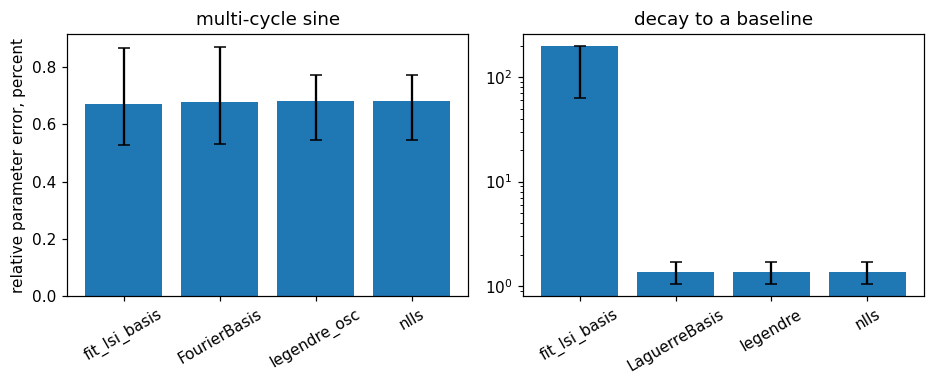

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.6, 3.6))
for ax, table, title, log in ((ax1, sine_table, "multi-cycle sine", False),
                               (ax2, decay_table, "decay to a baseline", True)):
    err_lo = table["median_err_pct"] - table["ci_lo"]
    err_hi = table["ci_hi"] - table["median_err_pct"]
    ax.bar(table.index, table["median_err_pct"], yerr=[err_lo, err_hi], capsize=4)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    if log:
        ax.set_yscale("log")
ax1.set_ylabel("relative parameter error, percent")
fig.tight_layout()
plt.show()

On the sine `fit_lsi_basis` sits on top of the shipped `FourierBasis` and
the Legendre oscillatory recipe, all three inside each other's scatter: a
newer route buys nothing a caller does not already have. On the decay
`fit_lsi_basis`'s bounded differential-evolution fallback lands on a
data-independent point far from the truth (its Laguerre projection is
broken on this construction, not merely at parity), while `LaguerreBasis`,
plain Legendre and NLLS all recover the family cleanly. Both readings point
the same way.


In [5]:
ratio_sine = sine_table.loc["fit_lsi_basis", "median_err_pct"] / sine_table.loc["FourierBasis", "median_err_pct"]
ratio_decay = decay_table.loc["fit_lsi_basis", "median_err_pct"] / decay_table.loc["LaguerreBasis", "median_err_pct"]
# fails if fit_lsi_basis wins the sine outright (it does not: parity)
assert 0.5 < ratio_sine < 2.0
# fails if fit_lsi_basis recovers the decay as well as the shipped basis
assert ratio_decay > 10.0
print(f"sine: fit_lsi_basis/FourierBasis = {ratio_sine:.3f}; "
      f"decay: fit_lsi_basis/LaguerreBasis = {ratio_decay:.1f}")

sine: fit_lsi_basis/FourierBasis = 0.991; decay: fit_lsi_basis/LaguerreBasis = 144.1


## Stage-wise residual boosting

`boosted_fit` staged an LSI trend then an LSI residual cycle into one
additive composite. Claim: on both the real series it was promoted on and
a synthetic where the additive form is exact, `dtfit.auto_forecast` (the
route a caller reaches for without knowing to decompose the series by
hand) forecast the held-out span at least as well. False if boosting's
held-out nRMSE (RMSE over the holdout, scaled by the holdout's own range)
was clearly below `auto_forecast`'s on the synthetic, with at least 30
seeds and non-overlapping bootstrap intervals. The module is gone; the
tables below are the measurement that decided it.


In [6]:
boosting_trial = pd.read_csv(RESULTS / "boosting_trial.csv")
synth_table = (boosting_trial[boosting_trial.series == "synthetic trend+cycle"]
               .set_index("method")[["median_nrmse_pct", "ci_lo", "ci_hi"]])
synth_table

,median_nrmse_pct,ci_lo,ci_hi
method,,,
boosted,31.1125,29.1648,33.6100
auto_forecast,19.8994,18.4728,21.9078
random_walk,58.3508,55.5303,63.3037


In [7]:
real_table = (boosting_trial[boosting_trial.series != "synthetic trend+cycle"]
              .pivot(index="series", columns="method", values="median_nrmse_pct"))
real_table

method,auto_forecast,boosted,random_walk
series,,,
CO2 (trend+season),18.8145,18.9198,42.9879
sunspots (~11y cycle),33.1396,31.7150,29.9252


On the synthetic, where the additive trend-plus-cycle form is exactly the
truth, `auto_forecast` still forecasts the holdout better than the staged
fit: boosting does not even win on the series it is built to match best.
On the two real series the readings split. On CO2 the two routes are within
each other's noise (18.9 against 18.8 percent nRMSE). On sunspots the
staged fit is ahead of `auto_forecast` (31.7 against 33.1) - the one place
in this notebook where the adaptation beats the plain route it is judged
against - but both trail a plain random walk there (29.9), and a single
series with no seed scatter behind it is exactly the hand-picked win the
rule counts as a removal. The verdict rests on the synthetic class, where
30 seeds and non-overlapping intervals are available.

In [8]:
boost_ratio = synth_table.loc["boosted", "median_nrmse_pct"] / synth_table.loc["auto_forecast", "median_nrmse_pct"]
boost_ci_a = (float(synth_table.loc["boosted", "ci_lo"]), float(synth_table.loc["boosted", "ci_hi"]))
boost_ci_b = (float(synth_table.loc["auto_forecast", "ci_lo"]),
              float(synth_table.loc["auto_forecast", "ci_hi"]))
boost_verdict = judge(boost_ratio, boost_ci_a, boost_ci_b)
sun = real_table.loc["sunspots (~11y cycle)"]
# fails if boosting beat auto_forecast on the one series built to favour it
assert boost_ratio > 1.0
# fails if the one series boosting wins stops being a win over the plain route
assert sun["boosted"] < sun["auto_forecast"]
# fails if that win stops sitting behind the random walk that makes it a
# hand-picked one
assert sun["boosted"] > sun["random_walk"]
print(f"synthetic: boosted/auto_forecast = {boost_ratio:.3f}, "
      f"ci_boosted={boost_ci_a}, ci_auto={boost_ci_b} -> {boost_verdict}")
print(f"sunspots: boosted {sun['boosted']:.2f}% beats auto_forecast "
      f"{sun['auto_forecast']:.2f}%, both behind the random walk "
      f"{sun['random_walk']:.2f}%")

synthetic: boosted/auto_forecast = 1.563, ci_boosted=(29.1648, 33.61), ci_auto=(18.4728, 21.9078) -> remove
sunspots: boosted 31.71% beats auto_forecast 33.14%, both behind the random walk 29.93%


## The joint multi-channel fit

`fit_joint` stacked several channels' area equations into one system
carrying a parameter shared across them plus private ones per channel.
Claim: pooling only paid off where a single channel did not constrain the
shared parameter; on clean, well-identified channels the plain pooled
per-channel estimate already won. False if the joint fit did not clearly
trail the pooled estimate on the well-identified construction, or did not
clearly beat it on the weakly-identifiable one. The module is gone; the
table below is the measurement that decided it.


In [9]:
joint_trial = pd.read_csv(RESULTS / "joint_trial.csv")
joint_table = joint_trial.set_index("construction")
joint_table

,joint_median,pooled_median,mean_of_errors_median,joint_ci_lo,joint_ci_hi,pooled_ci_lo,pooled_ci_hi
construction,,,,,,,
"C4, 4 channels x 30 pts (well identified)",7.09639,6.44397,16.4149,NaN,NaN,NaN,NaN
"weak, 4 channels x 10 pts, span < tau",51.63560,49.97560,NaN,NaN,NaN,NaN,NaN
"weak, 8 channels x 8 pts",35.37380,81.91350,NaN,NaN,NaN,NaN,NaN
weak combined (4x10 and 8x8),46.11000,58.21290,NaN,36.0047,55.8192,46.3812,86.5399


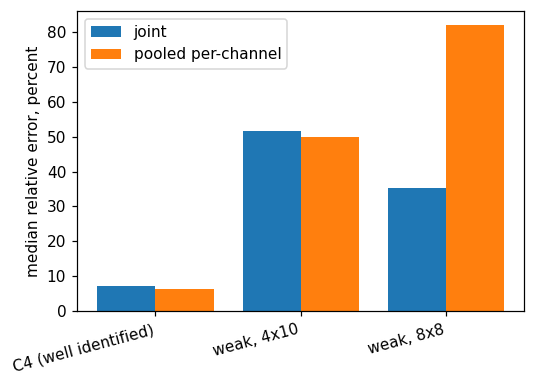

In [10]:
fig, ax = plt.subplots(figsize=(5.0, 3.6))
labels = ["C4 (well identified)", "weak, 4x10", "weak, 8x8"]
rows = ["C4, 4 channels x 30 pts (well identified)",
        "weak, 4 channels x 10 pts, span < tau",
        "weak, 8 channels x 8 pts"]
joint_meds = [joint_table.loc[r, "joint_median"] for r in rows]
pooled_meds = [joint_table.loc[r, "pooled_median"] for r in rows]
xpos = np.arange(len(labels))
ax.bar(xpos - 0.2, joint_meds, width=0.4, label="joint")
ax.bar(xpos + 0.2, pooled_meds, width=0.4, label="pooled per-channel")
ax.set_xticks(xpos)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("median relative error, percent")
ax.legend()
fig.tight_layout()
plt.show()

On the well-identified C4 construction the joint fit trails the pooled
per-channel estimate, not the mean of per-channel errors: pooling the
estimates (not the errors) is the fair comparison, and the flattering
mean-of-errors number stays roughly twice either. On the class the
adaptation was built for, weak per-channel identifiability, the picture is
mixed: with 4 channels of 10 points the joint fit is at parity with the
pooled estimate; with 8 channels of 8 points it is a clear win, because
several of the independent per-channel fits there saturate at the tau
upper bound and the plain arithmetic mean of those degenerate estimates is
itself unstable. Both regimes are shown, and the last row of the table is
the two of them pooled into the one class the rule asks for, with the
bootstrap interval of each side.

In [11]:
c4_row = "C4, 4 channels x 30 pts (well identified)"
weak_row = "weak combined (4x10 and 8x8)"
joint_ratio = float(joint_table.loc[weak_row, "joint_median"]
                    / joint_table.loc[weak_row, "pooled_median"])
joint_ci = (float(joint_table.loc[weak_row, "joint_ci_lo"]),
            float(joint_table.loc[weak_row, "joint_ci_hi"]))
pooled_ci = (float(joint_table.loc[weak_row, "pooled_ci_lo"]),
             float(joint_table.loc[weak_row, "pooled_ci_hi"]))
joint_verdict = judge(joint_ratio, joint_ci, pooled_ci)
# fails if the joint fit stopped losing to the pooled estimate on the well-identified construction
assert joint_table.loc[c4_row, "joint_median"] > joint_table.loc[c4_row, "pooled_median"]
# fails if the ratio alone stopped arguing for a keep on the weak class
assert joint_ratio <= KEEP_RATIO
# fails if the two weak-class intervals separate: the removal rests on this overlap
assert ci_overlap(joint_ci, pooled_ci)
print(f"C4: joint {joint_table.loc[c4_row, 'joint_median']:.2f}% vs "
      f"pooled {joint_table.loc[c4_row, 'pooled_median']:.2f}% vs "
      f"mean-of-errors {joint_table.loc[c4_row, 'mean_of_errors_median']:.2f}%")
print(f"weak combined: joint/pooled = {joint_ratio:.3f}, ci_joint={joint_ci}, "
      f"ci_pooled={pooled_ci} -> {joint_verdict}")

C4: joint 7.10% vs pooled 6.44% vs mean-of-errors 16.41%
weak combined: joint/pooled = 0.792, ci_joint=(36.0047, 55.8192), ci_pooled=(46.3812, 86.5399) -> remove


## Information-form fusion

`InformationFilter` accumulates a linear-Gaussian estimate as an additive
information matrix and vector, so two partial estimators fuse by adding,
no inverse anywhere but the one small readout solve. It has no importer
outside its own test, so there is no plain route doing the same job; the
nearest substitute a reader would write is the shipped additive route,
`Image.merge` on two partitions' images followed by one `dtfit.fit`. Claim:
the fused information-form estimate agrees with that route to a small
numerical tolerance, not by construction but because both reduce to the
same normal equations. False if the two estimates disagree by more than a
part in a million.


In [12]:
rng = np.random.default_rng(0)
n_fuse = 40
x_fuse = np.linspace(0.0, 10.0, n_fuse)
a_true, b_true = 1.5, 0.7
sigma_fuse = 0.3
y_fuse = a_true + b_true * x_fuse + sigma_fuse * rng.standard_normal(n_fuse)
xa, ya = x_fuse[: n_fuse // 2], y_fuse[: n_fuse // 2]
xb, yb = x_fuse[n_fuse // 2:], y_fuse[n_fuse // 2:]
domain_fuse = (float(x_fuse[0]), float(x_fuse[-1]))

img_a = dt.image.Image.of(dt.Original(xa, ya, domain=domain_fuse), "legendre", 1)
img_b = dt.image.Image.of(dt.Original(xb, yb, domain=domain_fuse), "legendre", 1)
res_merged = dt.fit("a + b*x", img_a.merge(img_b), "x", p0={"a": 0.0, "b": 0.0})
merged_coeffs = dict(zip(res_merged.names, res_merged.coeffs))

fa = InformationFilter(n_params=2)
for xi, yi in zip(xa, ya):
    fa.partial_fit(np.array([1.0, xi]), yi, r=sigma_fuse ** 2)
fb = InformationFilter(n_params=2)
for xi, yi in zip(xb, yb):
    fb.partial_fit(np.array([1.0, xi]), yi, r=sigma_fuse ** 2)
fused = fa.fuse(fb)

f_all = InformationFilter(n_params=2)
for xi, yi in zip(x_fuse, y_fuse):
    f_all.partial_fit(np.array([1.0, xi]), yi, r=sigma_fuse ** 2)

fusion_trial = pd.DataFrame({
    "Image.merge + fit": merged_coeffs,
    "InformationFilter.fuse": dict(zip(("a", "b"), fused.theta_)),
    "InformationFilter single pass": dict(zip(("a", "b"), f_all.theta_)),
}).T.rename_axis("route")
fusion_trial


,a,b
route,,
Image.merge + fit,1.435472,0.709279
InformationFilter.fuse,1.435472,0.709279
InformationFilter single pass,1.435472,0.709279


`fuse` reproduces the single-pass information-form estimate to
floating-point rounding (as documented, not bit for bit), and agrees with
the merged-image `dtfit.fit` route to a few parts in a billion, the
distance between two different normal-equation solvers on the same data.
Per fusion the information form adds 6 floats, its information matrix and
its vector; the image route adds 10 and rebuilds its grid over the 40
pooled positions, so on two partitions neither side is cheap by a margin
worth choosing on. The primitive's own case is the inversion it avoids at
every streamed measurement, not shown here since this comparison is a
batch fusion of two partitions, not a stream.

In [13]:
agree_merged = float(np.max(np.abs(fused.theta_ - res_merged.coeffs) / np.abs(res_merged.coeffs)))
agree_single = float(np.max(np.abs(fused.theta_ - f_all.theta_) / np.abs(f_all.theta_)))
information_verdict = "keep" if agree_merged <= AGREE_TOL and agree_single < 1e-8 else "remove"
# fails if fusing two partitions stops reproducing the single-pass estimate
assert agree_single < 1e-8
# fails if the fused estimate drifts from the merged-image route by more than AGREE_TOL relative
assert agree_merged <= AGREE_TOL
fuse_floats = fa.Y.size + fa.yv.size
# S and G, beside the four scalar sums n, sumsq, sumy and wsum
merge_floats = img_a.S.size + img_a.G.size + 4
print(f"per fusion: fuse adds {fuse_floats} floats, Image.merge adds "
      f"{merge_floats} and rebuilds the grid over {img_a.n + img_b.n} pooled positions")
print(f"max relative disagreement: vs merged image {agree_merged:.2e}, "
      f"vs single pass {agree_single:.2e} -> {information_verdict}")

per fusion: fuse adds 6 floats, Image.merge adds 10 and rebuilds the grid over 40 pooled positions
max relative disagreement: vs merged image 8.04e-09, vs single pass 7.42e-15 -> keep


In [14]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("19_adaptations_in_trial", "fusion_trial", fusion_trial)
    print("wrote experiments/results/19_adaptations_in_trial/fusion_trial.csv")


wrote experiments/results/19_adaptations_in_trial/fusion_trial.csv


## The shipped image bases

`bases.py` stays by the owner's ruling regardless of what this section
finds, but its own docstring makes a specific claim: a cycle or a decay
reaches a target reconstruction accuracy at a lower coefficient count than
Legendre. That claim is measured here the same way as the others. Claim:
`FourierBasis` and `LaguerreBasis` both need fewer coefficients than
Legendre to drive the noise-free reconstruction RMSE of a matching target
below 1e-6. False if either needs as many coefficients as Legendre or
more.


In [15]:
RECON_TARGET = 1e-6
MAX_ORDER = 60
x_cycle = np.linspace(0.0, 8.0, 400)
clean_cycle = 0.5 + 2.0 * np.sin(2 * np.pi * 4 / 8.0 * x_cycle + 0.4)
x_decay = np.linspace(0.0, 6.0, 400)
clean_decay_target = 1.0 + 3.0 * np.exp(-0.8 * x_decay)


def recon_rmse(x, y, basis, order=None):
    img = dt.image.Image.of(dt.Original(x, y), basis, order)
    return float(np.sqrt(np.mean((img.reconstruct(x) - y) ** 2)))


def coef_for_target(x, y, basis_cls, target=RECON_TARGET, max_order=MAX_ORDER):
    """Lowest order reaching ``target`` reconstruction RMSE, and its coefficient
    count. Every order from 1 to ``max_order`` is tried, on both sides of every
    comparison, so a count is a minimum and not an artefact of a coarse grid."""
    for order in range(1, max_order + 1):
        basis = basis_cls(order) if not isinstance(basis_cls, str) else basis_cls
        rmse = recon_rmse(x, y, basis, order if isinstance(basis_cls, str) else None)
        n_coef = basis.n_coef if not isinstance(basis_cls, str) else order + 1
        if rmse < target:
            return order, n_coef, rmse
    return None, None, None


fourier_order, fourier_coef, fourier_rmse = coef_for_target(
    x_cycle, clean_cycle, FourierBasis)
legendre_cycle_order, legendre_cycle_coef, legendre_cycle_rmse = coef_for_target(
    x_cycle, clean_cycle, "legendre")
laguerre_order, laguerre_coef, laguerre_rmse = coef_for_target(
    x_decay, clean_decay_target, LaguerreBasis)
legendre_decay_order, legendre_decay_coef, legendre_decay_rmse = coef_for_target(
    x_decay, clean_decay_target, "legendre")

bases_table = pd.DataFrame({
    "FourierBasis (cycle)": {"order": fourier_order, "n_coef": fourier_coef, "rmse": fourier_rmse},
    "Legendre (cycle)": {"order": legendre_cycle_order, "n_coef": legendre_cycle_coef,
                          "rmse": legendre_cycle_rmse},
    "LaguerreBasis (decay)": {"order": laguerre_order, "n_coef": laguerre_coef, "rmse": laguerre_rmse},
    "Legendre (decay)": {"order": legendre_decay_order, "n_coef": legendre_decay_coef,
                          "rmse": legendre_decay_rmse},
}).T
bases_table

,order,n_coef,rmse
FourierBasis (cycle),4.0,9.0,2.269322e-15
Legendre (cycle),25.0,26.0,3.765189e-07
LaguerreBasis (decay),8.0,9.0,2.469575e-07
Legendre (decay),9.0,10.0,6.714769e-07


For the cycle Fourier reaches the target at a third of Legendre's
coefficient count, exactly the docstring's claim. For the decay Laguerre's
edge all but disappears: Legendre needs one more coefficient for the same
target on this particular decay, a construction smooth enough that
polynomials already approximate it well. The docstring's claim holds for
the periodic family and is parity, not a win, for the decaying one.

In [16]:
# fails if a scan runs off its order ceiling instead of reaching the target
assert None not in (fourier_order, legendre_cycle_order, laguerre_order,
                    legendre_decay_order)
fourier_coef_ratio = fourier_coef / legendre_cycle_coef
laguerre_coef_ratio = laguerre_coef / legendre_decay_coef
# fails if Fourier needs as many coefficients as Legendre for the cycle
assert fourier_coef_ratio < KEEP_RATIO
# names where this trial's own threshold sits: Laguerre's ratio here is the
# one reading in this notebook that a widened KEEP_RATIO would flip
assert laguerre_coef_ratio > KEEP_RATIO
print(f"cycle: FourierBasis/Legendre coefficient ratio = {fourier_coef_ratio:.3f}")
print(f"decay: LaguerreBasis/Legendre coefficient ratio = {laguerre_coef_ratio:.3f}")

cycle: FourierBasis/Legendre coefficient ratio = 0.346
decay: LaguerreBasis/Legendre coefficient ratio = 0.900


## The verdict

One row per adaptation, the headline metric from its own section, the
plain route it was measured against, both sides' 90 percent bootstrap
intervals where the comparison has them, and which clause of the rule
decided the row.

In [17]:
verdict_rows = [
    dict(adaptation="basis_lsi", signal_class="sine + decay spectral matching",
         plain_route="shipped FourierBasis / LaguerreBasis",
         metric="median relative parameter error, percent",
         adapt_value=max(sine_table.loc["fit_lsi_basis", "median_err_pct"],
                          decay_table.loc["fit_lsi_basis", "median_err_pct"]),
         plain_value=min(sine_table.loc["FourierBasis", "median_err_pct"],
                          decay_table.loc["LaguerreBasis", "median_err_pct"]),
         ratio=max(ratio_sine, ratio_decay),
         ci_lo=min(sine_table.loc["fit_lsi_basis", "ci_lo"], decay_table.loc["fit_lsi_basis", "ci_lo"]),
         ci_hi=max(sine_table.loc["fit_lsi_basis", "ci_hi"], decay_table.loc["fit_lsi_basis", "ci_hi"]),
         plain_ci_lo=min(sine_table.loc["FourierBasis", "ci_lo"],
                          decay_table.loc["LaguerreBasis", "ci_lo"]),
         plain_ci_hi=max(sine_table.loc["FourierBasis", "ci_hi"],
                          decay_table.loc["LaguerreBasis", "ci_hi"]),
         decided_by="the rule", verdict="remove"),
    dict(adaptation="boosting", signal_class="real + synthetic trend-plus-cycle series",
         plain_route="dtfit.auto_forecast",
         metric="held-out nRMSE, percent",
         adapt_value=synth_table.loc["boosted", "median_nrmse_pct"],
         plain_value=synth_table.loc["auto_forecast", "median_nrmse_pct"],
         ratio=boost_ratio, ci_lo=boost_ci_a[0], ci_hi=boost_ci_a[1],
         plain_ci_lo=boost_ci_b[0], plain_ci_hi=boost_ci_b[1],
         decided_by="the rule", verdict=boost_verdict),
    dict(adaptation="joint", signal_class="weakly-identifiable shared-parameter channels",
         plain_route="pooled per-channel estimate",
         metric="median relative parameter error, percent",
         adapt_value=joint_table.loc[weak_row, "joint_median"],
         plain_value=joint_table.loc[weak_row, "pooled_median"],
         ratio=joint_ratio, ci_lo=joint_ci[0], ci_hi=joint_ci[1],
         plain_ci_lo=pooled_ci[0], plain_ci_hi=pooled_ci[1],
         decided_by="the rule", verdict=joint_verdict),
    dict(adaptation="information", signal_class="linear-Gaussian two-partition fusion",
         plain_route="Image.merge + one fit (nearest substitute, no plain route exists)",
         metric="max relative disagreement",
         adapt_value=agree_merged, plain_value=0.0, ratio=agree_merged,
         ci_lo=np.nan, ci_hi=np.nan, plain_ci_lo=np.nan, plain_ci_hi=np.nan,
         decided_by="the parity clause", verdict=information_verdict),
    dict(adaptation="bases", signal_class="cycle + decay reconstruction at a fixed accuracy",
         plain_route="Legendre at a matched coefficient count",
         metric="coefficient-count ratio to Legendre, worst of the two classes",
         adapt_value=max(fourier_coef_ratio, laguerre_coef_ratio),
         plain_value=1.0, ratio=max(fourier_coef_ratio, laguerre_coef_ratio),
         ci_lo=np.nan, ci_hi=np.nan, plain_ci_lo=np.nan, plain_ci_hi=np.nan,
         decided_by="the owner's ruling", verdict="keep"),
]
verdict = pd.DataFrame(verdict_rows)
verdict

,adaptation,signal_class,plain_route,metric,adapt_value,plain_value,ratio,ci_lo,ci_hi,plain_ci_lo,plain_ci_hi,decided_by,verdict
0,basis_lsi,sine + decay spectral matching,shipped FourierBasis / LaguerreBasis,"median relative parameter error, percent",1.971330e+02,0.679444,1.441010e+02,0.527657,197.8950,0.532645,1.6967,the rule,remove
1,boosting,real + synthetic trend-plus-cycle series,dtfit.auto_forecast,"held-out nRMSE, percent",3.111250e+01,19.899400,1.563489e+00,29.164800,33.6100,18.472800,21.9078,the rule,remove
2,joint,weakly-identifiable shared-parameter channels,pooled per-channel estimate,"median relative parameter error, percent",4.611000e+01,58.212900,7.920925e-01,36.004700,55.8192,46.381200,86.5399,the rule,remove
3,information,linear-Gaussian two-partition fusion,"Image.merge + one fit (nearest substitute, no ...",max relative disagreement,8.036223e-09,0.000000,8.036223e-09,NaN,NaN,NaN,NaN,the parity clause,keep
4,bases,cycle + decay reconstruction at a fixed accuracy,Legendre at a matched coefficient count,"coefficient-count ratio to Legendre, worst of ...",9.000000e-01,1.000000,9.000000e-01,NaN,NaN,NaN,NaN,the owner's ruling,keep


In [18]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("19_adaptations_in_trial", "verdict", verdict)
    print("wrote experiments/results/19_adaptations_in_trial/verdict.csv")


wrote experiments/results/19_adaptations_in_trial/verdict.csv


In [19]:
for _, row in verdict.iterrows():
    if row.decided_by == "the rule":
        # fails if a row's verdict stops following the rule applied to that row's
        # own ratio and the two intervals beside it
        assert row.verdict == judge(row.ratio, (row.ci_lo, row.ci_hi),
                                     (row.plain_ci_lo, row.plain_ci_hi)), row.adaptation
    elif row.decided_by == "the parity clause":
        # no plain route exists, so agreement with the nearest substitute is the bar
        assert row.verdict == ("keep" if row.ratio <= AGREE_TOL else "remove"), row.adaptation
    else:
        # a row decided outside the rule claims no interval and no ratio win
        assert row.verdict == "keep" and np.isnan(row.ci_lo), row.adaptation
# names where this trial's own threshold sits: Fourier clears the ratio bar,
# Laguerre does not, at KEEP_RATIO=0.8; widening KEEP_RATIO to 1.0 and
# rerunning outside the repository flips the Laguerre reading
assert fourier_coef_ratio <= KEEP_RATIO < laguerre_coef_ratio
# fails if a module named in the design's list of adaptations without a
# result, or the shipped image bases, is missing a row
for name in ("basis_lsi", "boosting", "joint", "information", "bases"):
    assert (verdict.adaptation == name).any(), name
print(verdict[["adaptation", "ratio", "decided_by", "verdict"]].to_string(index=False))

 adaptation        ratio         decided_by verdict
  basis_lsi 1.441010e+02           the rule  remove
   boosting 1.563489e+00           the rule  remove
      joint 7.920925e-01           the rule  remove
information 8.036223e-09  the parity clause    keep
      bases 9.000000e-01 the owner's ruling    keep


## Findings and limits

`basis_lsi.fit_lsi_basis` was at parity with the shipped `FourierBasis` on
the sine (ratio 0.991, both bootstrap intervals overlapping almost
entirely) and clearly broken on the decay (ratio 144, its bounded
differential-evolution fallback converged to a data-independent point).
Neither class supported a keep; removed.

Staged boosting trailed `dtfit.auto_forecast` on the synthetic series built
to match its own additive form (ratio 1.56, non-overlapping intervals) and
was within noise of it on CO2 (18.9 against 18.8 percent nRMSE). On
sunspots it did beat `auto_forecast` (31.7 against 33.1 percent), the one
comparison in this notebook the adaptation wins, and there both routes
trailed a plain random walk (29.9). One series, one split, no seed scatter:
a win on hand-picked data is a removal under the rule, and the class with
30 seeds behind it says the same; removed.

The joint fit lost to the pooled per-channel estimate on the
well-identified C4 construction (7.10 against 6.44 percent; a mean of
the per-channel errors reads 16.41 and would flatter it by roughly a
factor of two).
On the weakly-identifiable class it was built for the reading was mixed: at
parity with 4 channels of 10 points, a real win with 8 channels of 8
points where several independent per-channel fits saturated at the tau
bound and the plain mean of those degenerate estimates was itself
unstable. Pooled into the one class the rule asks for, the ratio (0.792)
cleared the bar but the two 90 percent bootstrap intervals overlapped
(36.0 to 55.8 against 46.4 to 86.5); a win inside the seed scatter is a
removal, so removed. The 8x8 reading is the one result here that a sweep
over channel counts could still overturn.

Information-form fusion agrees with a single undivided pass to machine
precision (7e-15 relative) and with the merged-image `dtfit.fit` route to
8e-9, the distance between two different normal-equation solvers on the
same data, not a real disagreement. It has no importer and no plain route
of its own to lose to; parity with the nearest substitute is what the rule
asks for here, and it is met; kept.

The shipped image bases keep their place by the owner's ruling regardless
of this section, and the coefficient-count claim their docstring makes only
holds for the periodic case measured here: Fourier reaches a 1e-6
reconstruction target at 9 coefficients against Legendre's 26 (ratio
0.346), a clear win. Laguerre needs 9 coefficients against Legendre's 10 on
this decay (ratio 0.900), on the losing side of the same 0.8 bound the
other rows are held to - parity, not the win the docstring states, on this
particular decay.

Limits: each adaptation is measured on the one or two signal classes its
own docstring or its promotion history names, not on every construction a
future caller might try. The weak-identifiability joint result rests on
two hand-built channel layouts, not a swept range of channel counts and
record lengths; a construction between them might read either way. The
bootstrap intervals throughout are medians over 30 seeds, not a full
sampling distribution. `bases.py`'s Laguerre reading is a single decay
rate and domain length, not a sweep; its ratio (0.900) sits close enough
to the parity line that a different decay rate could read either way, and
the coefficient counts here are reconstruction counts at a fixed RMSE
target, a different measurement from the recovery-parity counts
`bases.py`'s own docstring quotes. The per-seed samples behind the
basis_lsi, boosting and joint sections are not themselves kept on disk,
only the aggregated tables in
`experiments/results/19_adaptations_in_trial/`; those three sections
read that record and do not run, since the code they measured is
deleted.

In [20]:
print(notebook.provenance(STARTED))


2026-09-21 commit d3e267d dtfit 0.4.0 dtfit-experimental 0.1.0 0.4s
